# Final Experiments Evaluation

Evaluates the meta-policy (multiplier action mode) vs. the no-meta baseline
on `nyc_man_south`, brand momentum $\gamma=5$, brand momentum init $0.175$,
3 seeds (10/20/30), episode lengths $N \in \{7, 28\}$ — i.e. the
`final_experiments_bminit` W&B run group.

Run this notebook once those runs have finished to:
1. Build the headline mean-daily-profit table (mean/std over seeds, $N=7$
   and $N=28$ comparable) and print it as LaTeX.
2. Plot per-day brand momentum and per-day effective price scalar for the
   $N=28$ multiplier run (two separate single-column figures).

**Dry run:** to sanity-check the notebook before `final_experiments_bminit`
finishes, set `GROUP = "final_experiments"` and `SEEDS = [10]` in the config
cell below — those runs already have data.

**Requirements:** `wandb`, `pandas`, `numpy`, `matplotlib` (run
`pip install matplotlib` if missing — it's not in `requirements.txt`).
You must be logged in to W&B (`wandb login`).

In [7]:
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import wandb

ENTITY = "bertram-hage-danmarks-tekniske-universitet-dtu"
PROJECT = "deep_RL_project"

# --- Run set to evaluate ---
GROUP = "final_experiments"
BM_GAMMA = 5
CONFIGS = ["nometa", "mult"]  # baseline vs. meta-policy (multiplier mode)
DAYS = [7, 28]
SEEDS = [10, 20, 30]

api = wandb.Api()

In [8]:
runs = api.runs(f"{ENTITY}/{PROJECT}", filters={"group": GROUP})

name_re = re.compile(rf"^bmg{BM_GAMMA}_(mult|nometa)_d(\d+)_s(\d+)$")

run_lookup = {}
for run in runs:
    m = name_re.match(run.name)
    if m is None:
        continue
    cfg, n_days, seed = m.group(1), int(m.group(2)), int(m.group(3))
    if cfg in CONFIGS and n_days in DAYS and seed in SEEDS:
        run_lookup[(cfg, n_days, seed)] = run

expected = len(CONFIGS) * len(DAYS) * len(SEEDS)
print(f"Found {len(run_lookup)} / {expected} matching runs")
for key in sorted(run_lookup):
    print(key, "->", run_lookup[key].name, run_lookup[key].state)

Found 4 / 12 matching runs
('mult', 7, 10) -> bmg5_mult_d7_s10 failed
('mult', 28, 10) -> bmg5_mult_d28_s10 failed
('nometa', 7, 10) -> bmg5_nometa_d7_s10 finished
('nometa', 28, 10) -> bmg5_nometa_d28_s10 crashed


In [9]:
rows = []
for (cfg, n_days, seed), run in run_lookup.items():
    summary = run.summary
    rows.append({
        "config": cfg,
        "days": n_days,
        "seed": seed,
        "state": run.state,
        "episode": summary.get("episode"),
        "agent0_profit": summary.get("agent0/true_profit", np.nan),
        "agent1_profit": summary.get("agent1/true_profit", np.nan),
    })

df = pd.DataFrame(rows)
df["total_profit"] = df["agent0_profit"] + df["agent1_profit"]

# Per-day profit so N=7 and N=28 episodes are directly comparable.
for col in ["agent0_profit", "agent1_profit", "total_profit"]:
    df[f"{col}_daily"] = df[col] / df["days"]

df.sort_values(["days", "config", "seed"]).reset_index(drop=True)

,config,days,seed,state,episode,agent0_profit,agent1_profit,total_profit,agent0_profit_daily,agent1_profit_daily,total_profit_daily
0,mult,7,10,failed,67929,82979.062500,81938.117188,164917.179688,11854.151786,11705.445312,23559.597098
1,nometa,7,10,finished,100000,86334.335938,84534.773438,170869.109375,12333.476562,12076.396205,24409.872768
2,mult,28,10,failed,37653,284961.906250,281067.812500,566029.718750,10177.210938,10038.136161,20215.347098
3,nometa,28,10,crashed,85007,312489.312500,310108.468750,622597.781250,11160.332589,11075.302455,22235.635045


In [ ]:
CONFIG_LABELS = {"nometa": "No Meta", "mult": "Meta (mult)"}

agg = df.groupby(["days", "config"])[["agent0_profit_daily", "agent1_profit_daily", "total_profit_daily"]].agg(["mean", "std"])


def fmt(n_days, cfg, col):
    try:
        m = agg.loc[(n_days, cfg), (col, "mean")]
        s = agg.loc[(n_days, cfg), (col, "std")]
    except KeyError:
        return "N/A"
    if pd.isna(m):
        return "N/A"
    if pd.isna(s):
        s = 0.0
    return f"{m:,.1f} ({s:,.1f})"


latex = r"""\begin{table}[t]
\centering
\caption{Average daily profit [\$] with and without the meta-policy. Mean (std) over 3 seeds}
\label{tab:meta_vs_baseline}
\begin{tabular}{ll ccc}
\toprule
$N$ & Policy & Agent 0 & Agent 1 & Total \\
\midrule
\multirow{2}{*}{7}  & No Meta     & %s & %s & %s \\
                    & Meta & %s & %s & %s \\
\midrule
\multirow{2}{*}{28} & No Meta     & %s & %s & %s \\
                    & Meta & %s & %s & %s \\
\bottomrule
\end{tabular}
\end{table}""" % (
    fmt(7, "nometa", "agent0_profit_daily"), fmt(7, "nometa", "agent1_profit_daily"), fmt(7, "nometa", "total_profit_daily"),
    fmt(7, "mult", "agent0_profit_daily"), fmt(7, "mult", "agent1_profit_daily"), fmt(7, "mult", "total_profit_daily"),
    fmt(28, "nometa", "agent0_profit_daily"), fmt(28, "nometa", "agent1_profit_daily"), fmt(28, "nometa", "total_profit_daily"),
    fmt(28, "mult", "agent0_profit_daily"), fmt(28, "mult", "agent1_profit_daily"), fmt(28, "mult", "total_profit_daily"),
)

print(latex)

\begin{table}[t]
\centering
\caption{Mean daily profit [\$] with and without the meta-policy ($\gamma=5$, multiplier action mode). Mean (std) over 3 seeds.}
\label{tab:meta_vs_baseline}
\begin{tabular}{ll ccc}
\toprule
$N$ & Policy & Agent 0 & Agent 1 & Total \\
\midrule
\multirow{2}{*}{7}  & No Meta     & 12,333.5 (0.0) & 12,076.4 (0.0) & 24,409.9 (0.0) \\
                    & Meta (mult) & 11,854.2 (0.0) & 11,705.4 (0.0) & 23,559.6 (0.0) \\
\midrule
\multirow{2}{*}{28} & No Meta     & 11,160.3 (0.0) & 11,075.3 (0.0) & 22,235.6 (0.0) \\
                    & Meta (mult) & 10,177.2 (0.0) & 10,038.1 (0.0) & 20,215.3 (0.0) \\
\bottomrule
\end{tabular}
\end{table}


## Per-day brand momentum & effective price scalar ($N=28$)

Uses the converged (final-episode) per-day debug metrics
`debug/agent{a}_brand_momentum_d{d}` and `debug/agent{a}_mean_eff_price_d{d}`,
averaged across seeds, for the multiplier (meta) and no-meta runs.

In [11]:
PLOT_DAYS = 28
PLOT_CONFIGS = ["mult"]

day_idx = np.arange(PLOT_DAYS)
day_data = {}

for cfg in PLOT_CONFIGS:
    for agent in (0, 1):
        for metric in ("brand_momentum", "mean_eff_price"):
            seed_arrays = []
            for seed in SEEDS:
                run = run_lookup.get((cfg, PLOT_DAYS, seed))
                if run is None:
                    continue
                summary = run.summary
                seed_arrays.append([
                    summary.get(f"debug/agent{agent}_{metric}_d{d}", np.nan)
                    for d in range(PLOT_DAYS)
                ])
            if seed_arrays:
                day_data[(cfg, agent, metric)] = np.nanmean(np.array(seed_arrays, dtype=float), axis=0)
            else:
                day_data[(cfg, agent, metric)] = np.full(PLOT_DAYS, np.nan)

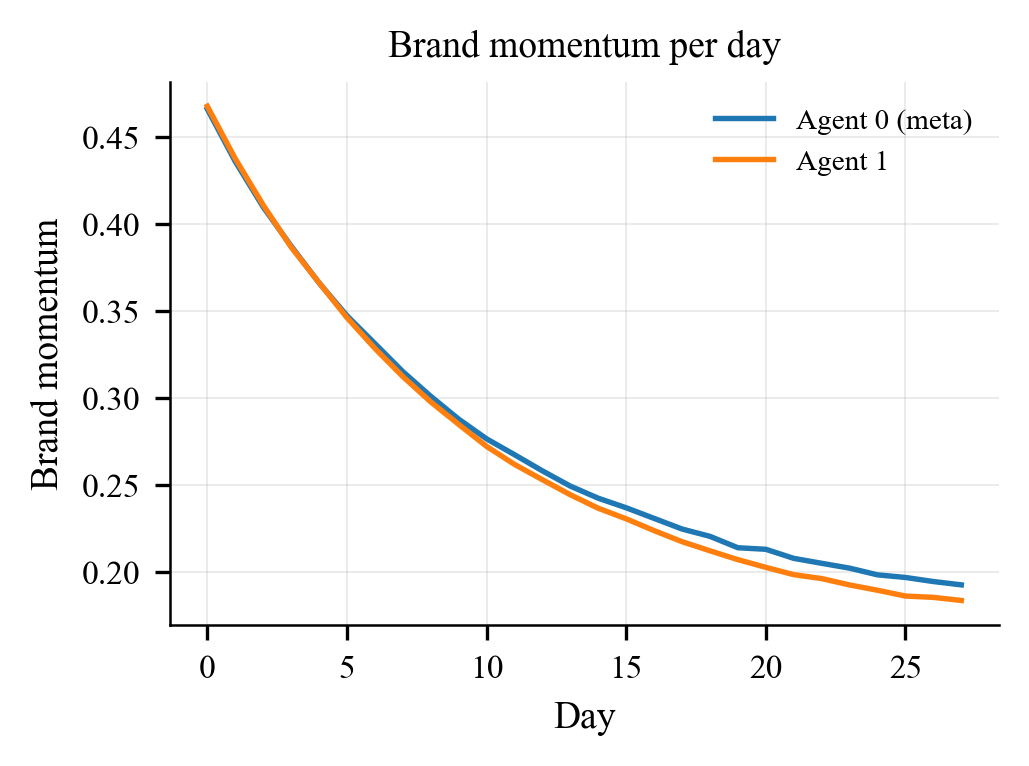

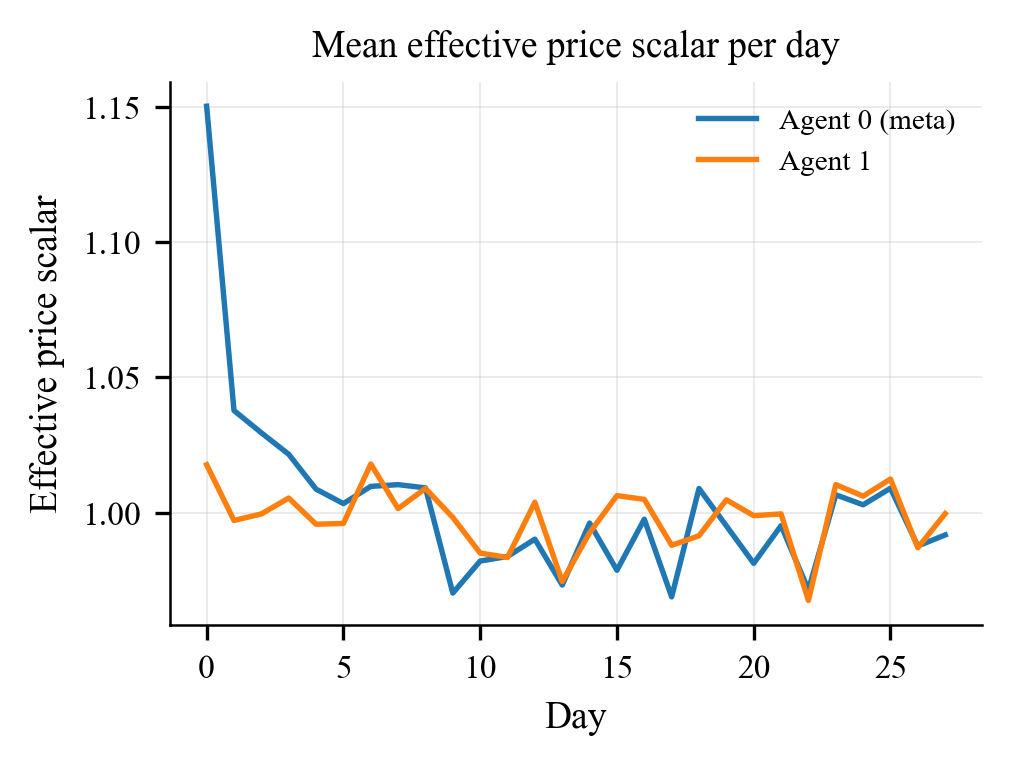

In [12]:
# IEEE single-column-friendly styling
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif"],
    "mathtext.fontset": "stix",
    "font.size": 9,
    "axes.labelsize": 9,
    "axes.titlesize": 9,
    "legend.fontsize": 7,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "axes.linewidth": 0.6,
    "lines.linewidth": 1.3,
    "grid.linewidth": 0.4,
    "figure.dpi": 300,
    "savefig.dpi": 300,
})

styles = {
    0: dict(color="tab:blue", linestyle="-", label="Agent 0 (meta)"),
    1: dict(color="tab:orange", linestyle="-", label="Agent 1"),
}

figures = [
    ("brand_momentum", "Brand momentum per day", "Brand momentum", "bm_per_day_d28.pdf"),
    ("mean_eff_price", "Mean effective price scalar per day", "Effective price scalar", "price_per_day_d28.pdf"),
]

for metric, title, ylabel, filename in figures:
    fig, ax = plt.subplots(figsize=(3.5, 2.625))
    for agent, style in styles.items():
        ax.plot(day_idx, day_data[("mult", agent, metric)], **style)
    ax.set_title(title)
    ax.set_xlabel("Day")
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.3)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.legend(frameon=False, loc="best")
    fig.tight_layout()
    fig.savefig(f"figures/{filename}", bbox_inches="tight")
    plt.show()